# Classificação de Grãos de Trigo — Seeds Dataset (CRISP-DM)

## Configuração

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from data_loader import load_data
from preprocessing import preprocess
from visualization import save_histograms, save_boxplots, save_correlation, save_pairplot
from train_models import train_all
from evaluate import evaluate_model, compare_models
from optimize import optimize_all, optimization_summary
from utils import feature_importance

FIGURES_DIR = '../assets'
os.makedirs(FIGURES_DIR, exist_ok=True)
print('Setup OK')


Setup OK


## 1. Carregamento dos Dados

In [2]:
df = load_data('../src/data/seeds_dataset.txt')
print('Shape:', df.shape)
df.head()


Shape: (210, 8)


,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coef_assimetria,comprimento_sulco,classe
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


## 2. Compreensão dos Dados

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   area                210 non-null    float64
 1   perimetro           210 non-null    float64
 2   compacidade         210 non-null    float64
 3   comprimento_nucleo  210 non-null    float64
 4   largura_nucleo      210 non-null    float64
 5   coef_assimetria     210 non-null    float64
 6   comprimento_sulco   210 non-null    float64
 7   classe              210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.2 KB


In [4]:
df.describe()

,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coef_assimetria,comprimento_sulco,classe
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


In [5]:
print('Média por feature:')
print(df.drop('classe', axis=1).mean().round(4))
print()
print('Mediana por feature:')
print(df.drop('classe', axis=1).median().round(4))
print()
print('Desvio padrão por feature:')
print(df.drop('classe', axis=1).std().round(4))


Média por feature:
area                  14.8475
perimetro             14.5593
compacidade            0.8710
comprimento_nucleo     5.6285
largura_nucleo         3.2586
coef_assimetria        3.7002
comprimento_sulco      5.4081
dtype: float64

Mediana por feature:
area                  14.3550
perimetro             14.3200
compacidade            0.8734
comprimento_nucleo     5.5235
largura_nucleo         3.2370
coef_assimetria        3.5990
comprimento_sulco      5.2230
dtype: float64

Desvio padrão por feature:
area                  2.9097
perimetro             1.3060
compacidade           0.0236
comprimento_nucleo    0.4431
largura_nucleo        0.3777
coef_assimetria       1.5036
comprimento_sulco     0.4915
dtype: float64


## 3. Valores Ausentes

In [6]:
missing = df.isnull().sum()
print('Valores ausentes por coluna:')
print(missing)
print(f'\nTotal de valores ausentes: {missing.sum()}')
if missing.sum() > 0:
    n_before = len(df)
    df = df.dropna()
    print(f'Linhas removidas: {n_before - len(df)}')
else:
    print('Nenhum valor ausente encontrado. Nenhuma linha removida.')


Valores ausentes por coluna:
area                  0
perimetro             0
compacidade           0
comprimento_nucleo    0
largura_nucleo        0
coef_assimetria       0
comprimento_sulco     0
classe                0
dtype: int64

Total de valores ausentes: 0
Nenhum valor ausente encontrado. Nenhuma linha removida.


## 4. Visualizações Exploratórias

Salvo: ../assets/histograms.png


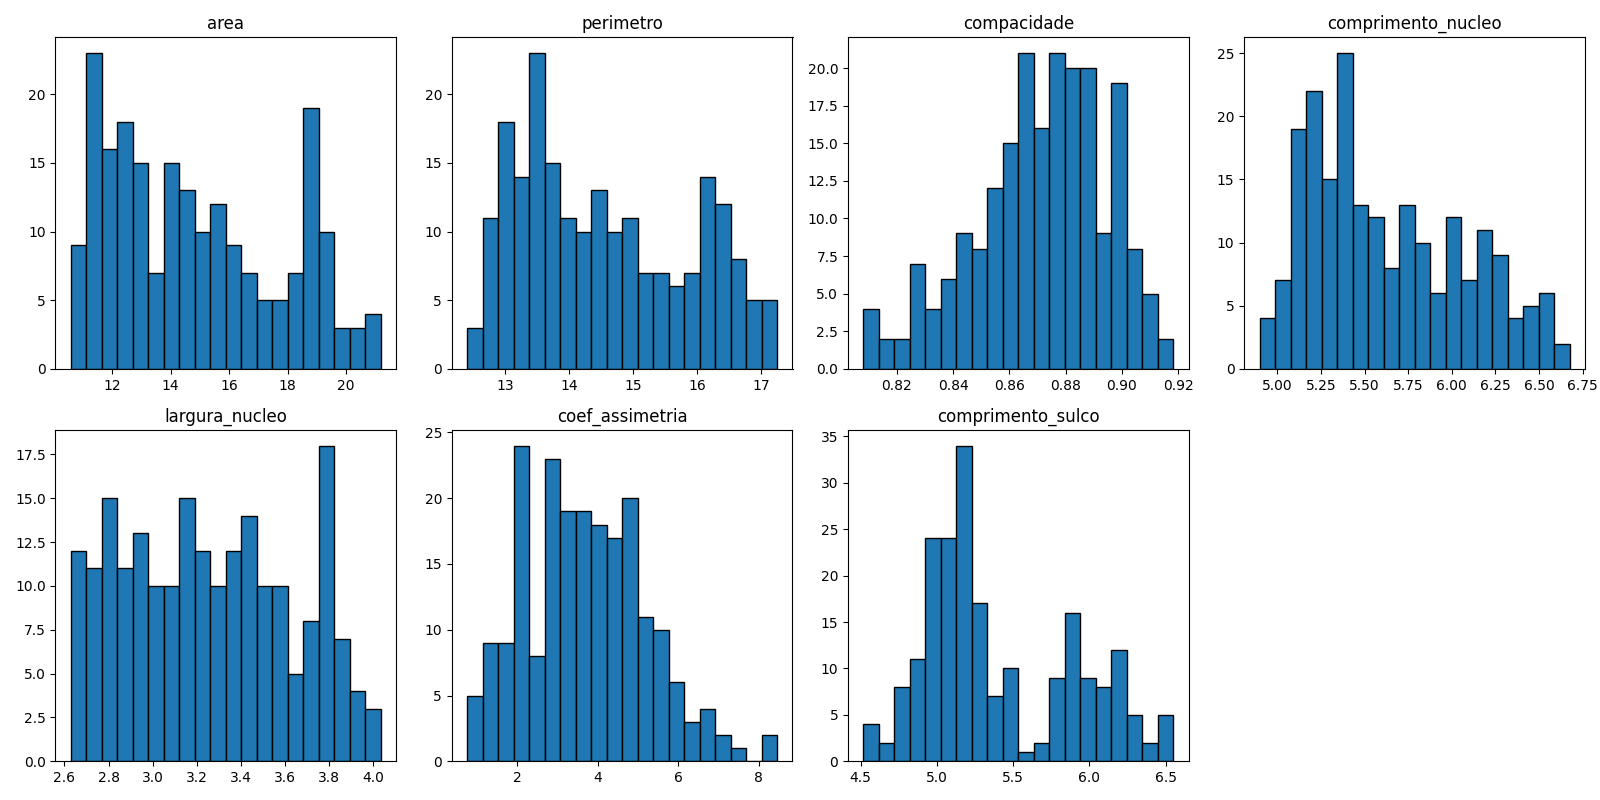

In [7]:
p = save_histograms(df, FIGURES_DIR)
print('Salvo:', p)
from IPython.display import Image
Image(p)


Salvo: ../assets/boxplots.png


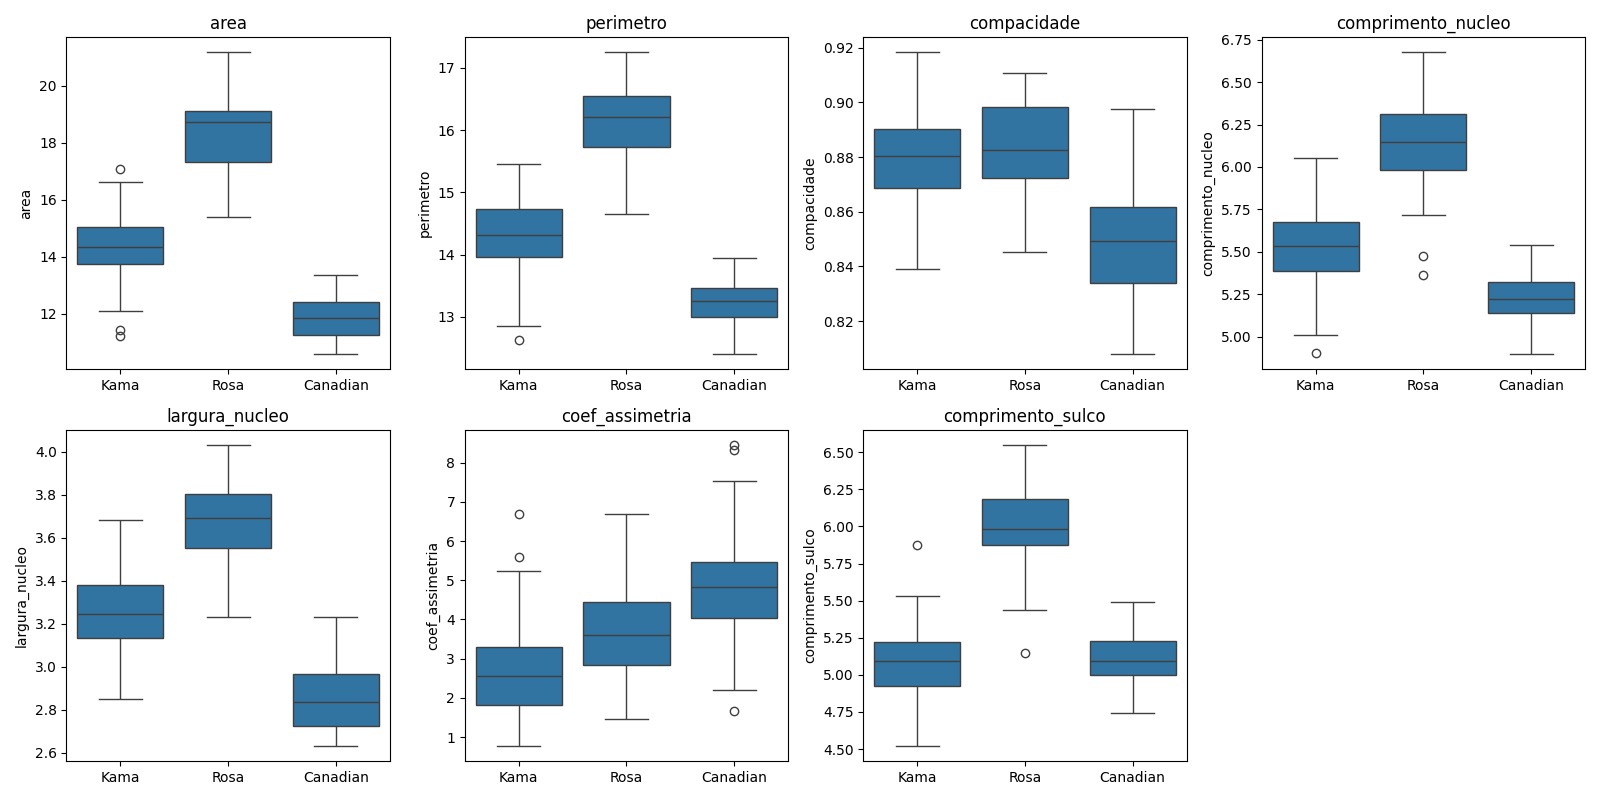

In [8]:
p = save_boxplots(df, FIGURES_DIR)
print('Salvo:', p)
Image(p)


Salvo: ../assets/correlation.png


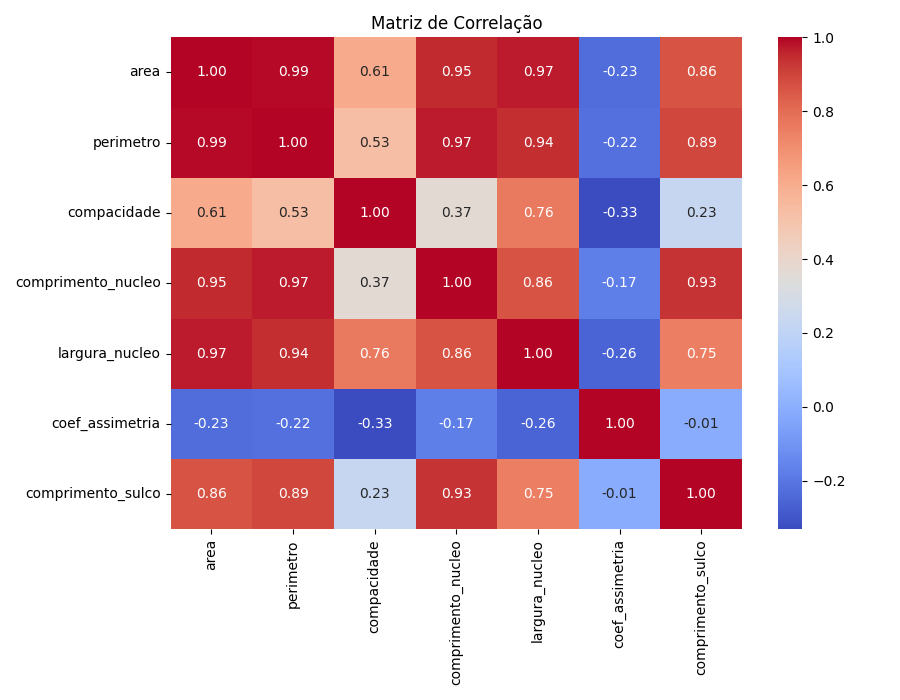

In [9]:
p = save_correlation(df, FIGURES_DIR)
print('Salvo:', p)
Image(p)


Salvo: ../assets/pairplot.png


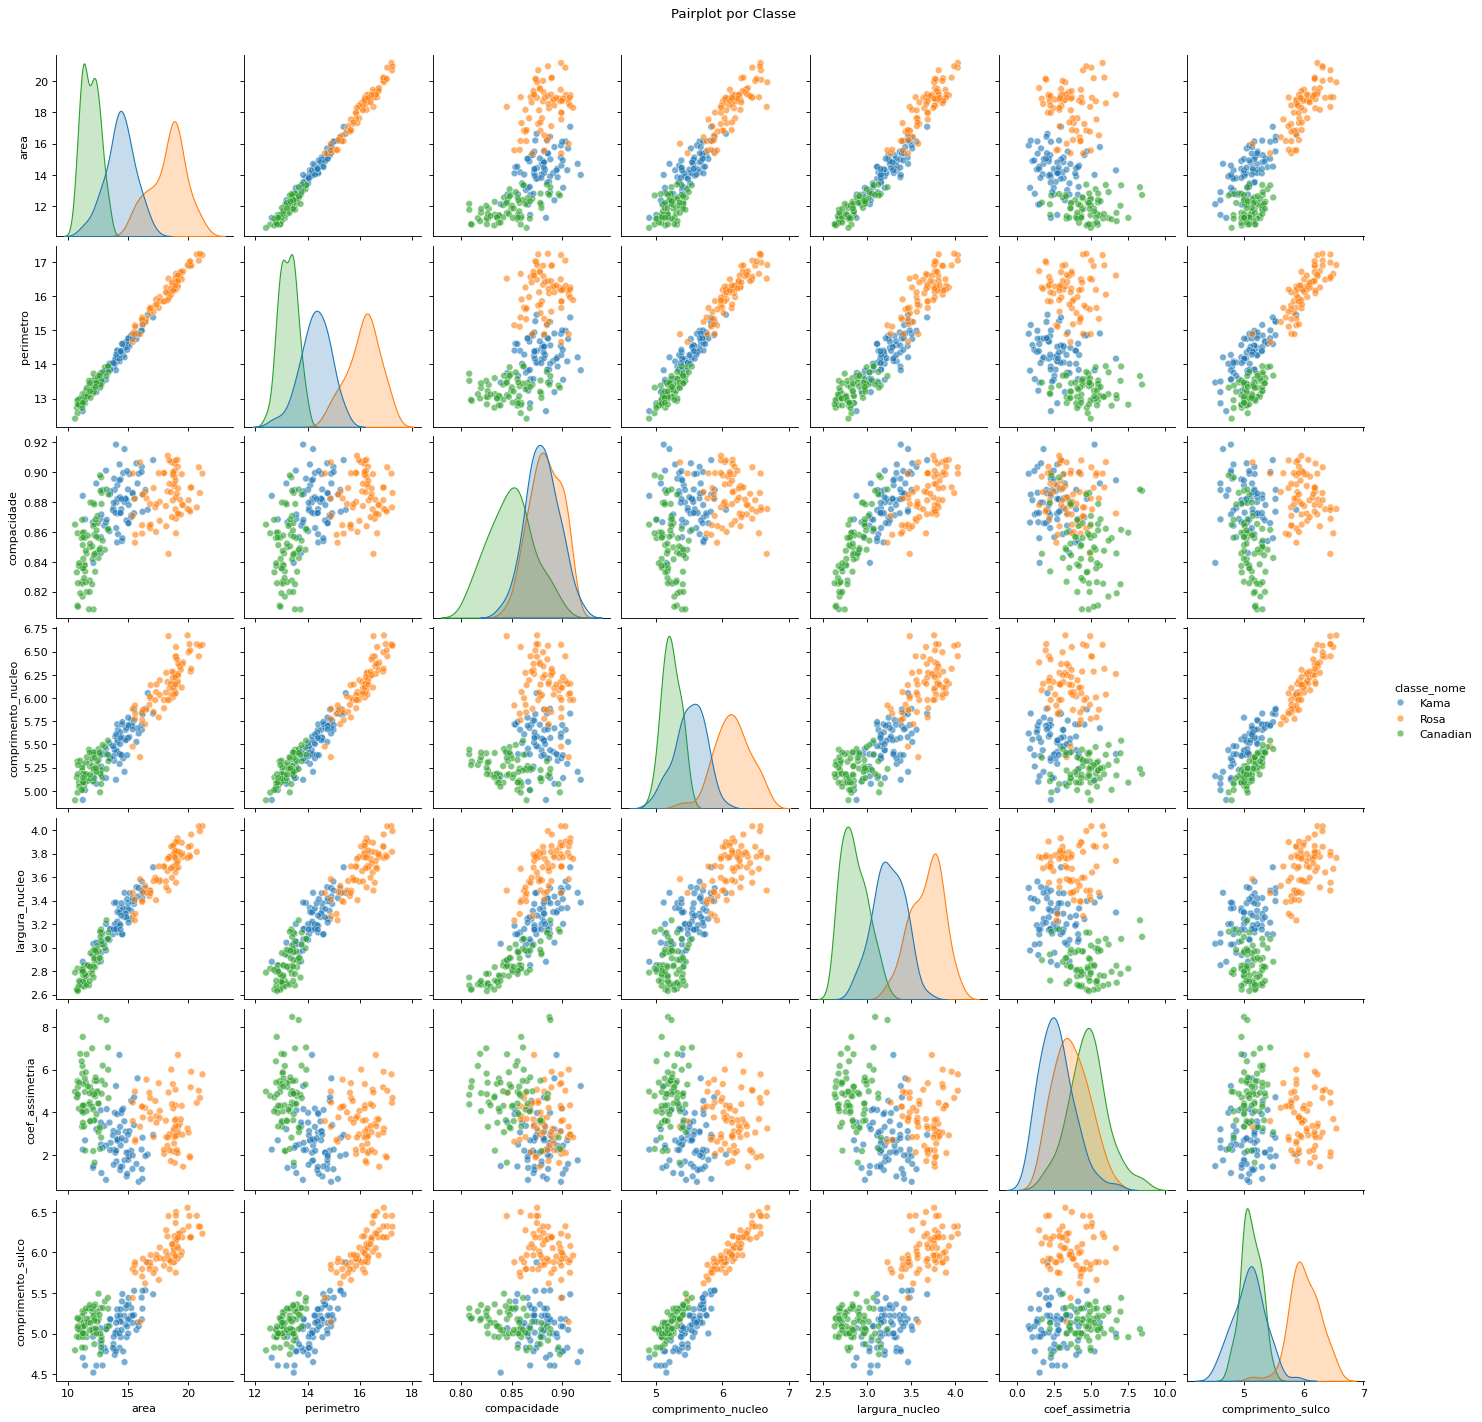

In [10]:
p = save_pairplot(df, FIGURES_DIR)
print('Salvo:', p)
Image(p)


## 5. Pré-processamento

In [11]:
X, y = preprocess(df)
print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (210, 7)
y shape: (210,)


## 6. Divisão Treino/Teste (70%/30%)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')
print('Distribuição treino:', dict(zip(*np.unique(y_train, return_counts=True))))
print('Distribuição teste: ', dict(zip(*np.unique(y_test, return_counts=True))))

# Escalonamento correto: fit apenas em treino, transform em treino e teste
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print('Média X_train após escalonamento (deve ser ~0):', X_train.mean(axis=0).round(4))
print('Desvio padrão X_train (deve ser ~1):', X_train.std(axis=0).round(4))


Treino: 147 amostras | Teste: 63 amostras
Distribuição treino: {np.int64(1): np.int64(49), np.int64(2): np.int64(49), np.int64(3): np.int64(49)}
Distribuição teste:  {np.int64(1): np.int64(21), np.int64(2): np.int64(21), np.int64(3): np.int64(21)}
Média X_train após escalonamento (deve ser ~0): [-0.  0. -0. -0. -0. -0. -0.]
Desvio padrão X_train (deve ser ~1): [1. 1. 1. 1. 1. 1. 1.]


## 7. Treinamento dos Modelos (KNN, SVM, Random Forest)

In [13]:
models = train_all(X_train, y_train)
print('Modelos treinados:', list(models.keys()))


Modelos treinados: ['KNN', 'SVM', 'Random Forest']


## 8. Avaliação dos Modelos

In [14]:
for name, model in models.items():
    metrics = evaluate_model(model, X_test, y_test)
    print(f'\n=== {name} ===')
    print(metrics['classification_report'])
    print('Confusion Matrix:')
    print(metrics['confusion_matrix'])



=== KNN ===
              precision    recall  f1-score   support

        Kama       0.84      0.76      0.80        21
        Rosa       0.90      0.90      0.90        21
    Canadian       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63

Confusion Matrix:
[[16  2  3]
 [ 2 19  0]
 [ 1  0 20]]

=== SVM ===
              precision    recall  f1-score   support

        Kama       0.84      0.76      0.80        21
        Rosa       0.90      0.90      0.90        21
    Canadian       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63

Confusion Matrix:
[[16  2  3]
 [ 2 19  0]
 [ 1  0 20]]

=== Random Forest ===
              precision    recall  f1-score   support

        Kama       0.94 

In [15]:
table = compare_models(models, X_test, y_test)
print('\nTabela Comparativa:')
table



Tabela Comparativa:


,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Modelo,,,,,
KNN,0.8730,0.8721,0.8730,0.8713,0.8713
SVM,0.8730,0.8721,0.8730,0.8713,0.8713
Random Forest,0.9206,0.9239,0.9206,0.9192,0.9192


## 9. Otimização dos Modelos com GridSearchCV (KNN, SVM, Random Forest)

In [16]:
opt_results = optimize_all(models, X_train, y_train, X_test, y_test)

for name, r in opt_results.items():
    print(f'\n========== {name} ==========')
    print('Melhores hiperparâmetros:', r['best_params'])
    print(f'Melhor score CV: {r["best_cv_score"]:.4f}')
    b, o = r['baseline_metrics'], r['optimized_metrics']
    print(f'Baseline  — Acc: {b["accuracy"]:.4f} | Prec: {b["precision_macro"]:.4f} | '
          f'Recall: {b["recall_macro"]:.4f} | F1: {b["f1_macro"]:.4f}')
    print(f'Otimizado — Acc: {o["accuracy"]:.4f} | Prec: {o["precision_macro"]:.4f} | '
          f'Recall: {o["recall_macro"]:.4f} | F1: {o["f1_macro"]:.4f}')
    print('Classification report (otimizado):')
    print(o['classification_report'])
    print('Matriz de confusão (otimizado):')
    print(o['confusion_matrix'])



========== KNN ==========
Melhores hiperparâmetros: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
Melhor score CV: 0.9460
Baseline  — Acc: 0.8730 | Prec: 0.8721 | Recall: 0.8730 | F1: 0.8713
Otimizado — Acc: 0.8889 | Prec: 0.8880 | Recall: 0.8889 | F1: 0.8881
Classification report (otimizado):
              precision    recall  f1-score   support

        Kama       0.85      0.81      0.83        21
        Rosa       0.90      0.90      0.90        21
    Canadian       0.91      0.95      0.93        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63

Matriz de confusão (otimizado):
[[17  2  2]
 [ 2 19  0]
 [ 1  0 20]]

========== SVM ==========
Melhores hiperparâmetros: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Melhor score CV: 0.9731
Baseline  — Acc: 0.8730 | Prec: 0.8721 | Recall: 0.8730 | F1: 0.8713
Otimizado — Acc: 0.8889 | Prec: 0.8908 | 

In [17]:
summary = optimization_summary(opt_results)
print('Comparativo baseline x otimizado:')
summary


Comparativo baseline x otimizado:


,Acc (baseline),Acc (otimizado),F1 macro (baseline),F1 macro (otimizado),Ganho Acc
Modelo,,,,,
KNN,0.8730,0.8889,0.8713,0.8881,0.0159
SVM,0.8730,0.8889,0.8713,0.8875,0.0159
Random Forest,0.9206,0.9206,0.9192,0.9192,0.0000


## 10. Importância das Features (Random Forest)

           feature  importance
              area    0.224700
         perimetro    0.217924
 comprimento_sulco    0.167378
    largura_nucleo    0.166256
comprimento_nucleo    0.116009
   coef_assimetria    0.061122
       compacidade    0.046612
Salvo: ../assets/feature_importance.png


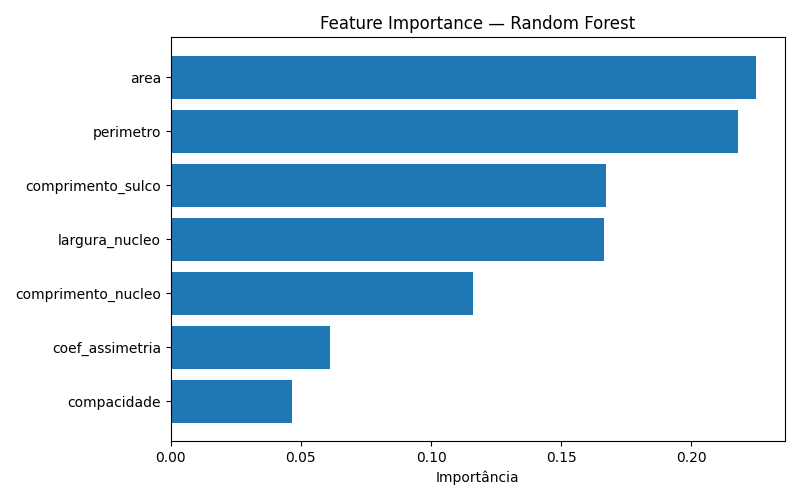

In [18]:
feature_names = ['area','perimetro','compacidade','comprimento_nucleo',
                 'largura_nucleo','coef_assimetria','comprimento_sulco']
fi = feature_importance(models['Random Forest'], feature_names)
print(fi.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi['feature'][::-1], fi['importance'][::-1])
ax.set_xlabel('Importância')
ax.set_title('Feature Importance — Random Forest')
plt.tight_layout()
p = os.path.join(FIGURES_DIR, 'feature_importance.png')
plt.savefig(p, dpi=100)
plt.close()
print('Salvo:', p)
Image(p)


## Conclusão

### Resultados (conjunto de teste — 63 amostras, 70/30 estratificado)

| Modelo | Accuracy (baseline) | Accuracy (otimizado) | F1 macro (otimizado) |
|--------|--------------------|----------------------|----------------------|
| KNN | 0.8730 | 0.8889 | 0.8881 |
| SVM | 0.8730 | 0.8889 | 0.8875 |
| **Random Forest** | **0.9206** | **0.9206** | **0.9192** |

Todos os modelos foram otimizados via **GridSearchCV (5-fold)**:
- **KNN** → `n_neighbors=3, weights='uniform', metric='manhattan'` (ganho de +1,6 p.p. de accuracy).
- **SVM** → `C=100, kernel='linear', gamma='scale'` (ganho de +1,6 p.p. de accuracy).
- **Random Forest** → `n_estimators=300, max_depth=None, max_features='sqrt', min_samples_split=2` (já era o melhor baseline; a otimização não trouxe ganho adicional no teste).

### Respostas às perguntas de negócio

1. **Qual modelo performou melhor?** O **Random Forest** obteve a maior accuracy (92,06%) e F1 macro (91,92%) no conjunto de teste, antes e depois da otimização.
2. **A otimização ajudou?** Sim para KNN e SVM (ambos subiram de 87,3% para 88,9%). O Random Forest já estava no seu melhor patamar, e o GridSearch confirmou a robustez dos hiperparâmetros padrão — não houve melhoria significativa adicional.
3. **Onde estão os erros?** As matrizes de confusão mostram que a confusão residual concentra-se entre **Kama** e as demais variedades (Kama é a classe com menor recall em todos os modelos), enquanto **Rosa** e **Canadian** são separadas com alta confiabilidade.
4. **Quais atributos mais importam?** Pela importância de features do Random Forest, as medidas geométricas do grão (área, perímetro e comprimento do sulco) são as mais discriminativas — coerente com o fato de as três variedades diferirem sobretudo no tamanho/forma.
5. **O problema foi resolvido / é viável para cooperativas de pequeno porte?** Sim. O modelo final é leve, interpretável e treinável em segundos em hardware modesto. As 7 medidas físicas são de fácil obtenção, tornando o sistema prático e confiável (>92% de acerto) para automatizar a classificação manual.
